<a href="https://colab.research.google.com/github/Springboard429/B12---PlantDocBot-AI-Plant-Disease-Diagnosis-via-Chat-and-Image-Upload/blob/Krishna-Raju/inference.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


✅ Model loaded successfully


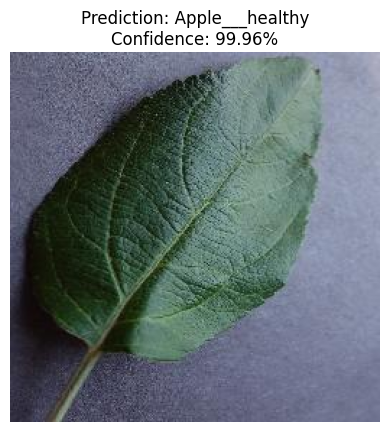

Predicted Class: Apple___healthy
Confidence: 99.96%


In [19]:
import torch
import torch.nn as nn
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import os


# 1. DEVICE (CPU)

device = torch.device("cpu")



# 2. CNN MODEL (MUST MATCH TRAINING)

class CNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 28 * 28, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x



# 3. LOAD SAVED MODEL

checkpoint = torch.load("/content/drive/MyDrive/best_cnn_plantdoc.pth", map_location=device)

class_names = checkpoint["class_names"]
num_classes = checkpoint["num_classes"]

model = CNN(num_classes)
model.load_state_dict(checkpoint["model_state_dict"])
model.to(device)
model.eval()

print("✅ Model loaded successfully")



# 4. IMAGE TRANSFORM

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])



# 5. PREDICTION FUNCTION (PATH-BASED)

def predict_image(image_path):
    if not os.path.exists(image_path):
        print("❌ Image path does not exist")
        return

    image = Image.open(image_path).convert("RGB")
    input_tensor = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(input_tensor)
        probs = torch.softmax(outputs, dim=1)
        confidence, pred_idx = torch.max(probs, 1)

    predicted_class = class_names[pred_idx.item()]
    confidence = confidence.item() * 100

    plt.imshow(image)
    plt.title(
        f"Prediction: {predicted_class}\nConfidence: {confidence:.2f}%"
    )
    plt.axis("off")
    plt.show()

    print("Predicted Class:", predicted_class)
    print("Confidence:", f"{confidence:.2f}%")



# 6. RUN INFERENCE (FULL IMAGE PATH)

if __name__ == "__main__":

    image_path = "/content/drive/MyDrive/APPLEHEALTHY.JPG"


    predict_image(image_path)